In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import make_scorer, accuracy_score, f1_score, roc_auc_score, precision_score, recall_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, KNNImputer
from sklearn.feature_selection import mutual_info_classif
import scipy.stats as stats
from sklearn.model_selection import RandomizedSearchCV
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_excel("Dataset 1 _ Pima Indians diabetes dataset (PIDD).xlsx")
df.head()

,Pregnancies,Glucose,Blood pressure,Skin thickness,Insulin,Body mass index,Diabetes pedigree function,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print(f"The data has {df.shape[0]} rows and {df.shape[1]} columns")

The data has 768 rows and 9 columns


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Pregnancies                 768 non-null    int64  
 1   Glucose                     768 non-null    int64  
 2   Blood pressure              768 non-null    int64  
 3   Skin thickness              768 non-null    int64  
 4   Insulin                     768 non-null    int64  
 5   Body mass index             768 non-null    float64
 6   Diabetes pedigree function  768 non-null    float64
 7   Age                         768 non-null    int64  
 8   Outcome                     768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe()

,Pregnancies,Glucose,Blood pressure,Skin thickness,Insulin,Body mass index,Diabetes pedigree function,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Visualizing the distribution of Outcome Variable

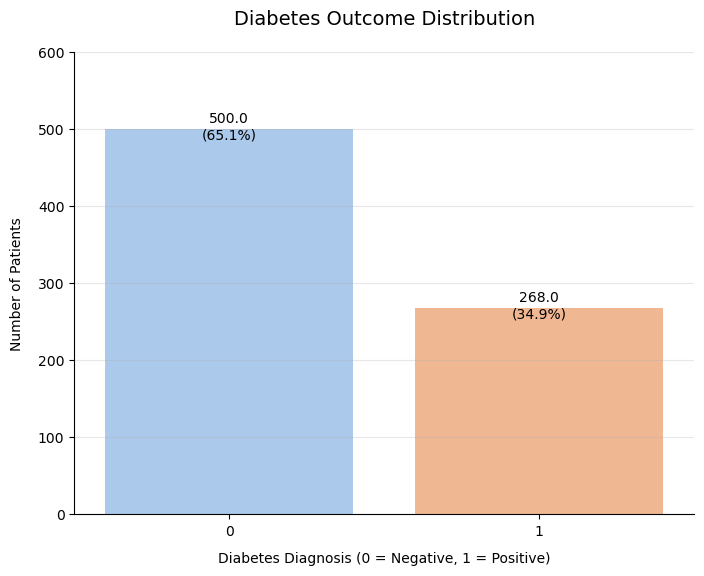

In [6]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Outcome', data = df, palette = 'pastel')

# Add count labels on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., 
            height + 3, 
            f'{height}\n({height/len(df)*100:.1f}%)', 
            ha='center', 
            va='center',
            fontsize=10)

plt.title('Diabetes Outcome Distribution', pad=20, fontsize=14)
plt.xlabel('Diabetes Diagnosis (0 = Negative, 1 = Positive)', labelpad=10)
plt.ylabel('Number of Patients', labelpad=10)
plt.ylim(0, max([p.get_height() for p in ax.patches]) * 1.20)
sns.despine()

# Add grid lines
plt.grid(axis='y', alpha=0.3)

plt.show()

In [7]:
# Separate independent features from the target feature
features = df.columns.drop('Outcome')

In [8]:
X = df[features]
y = df['Outcome']

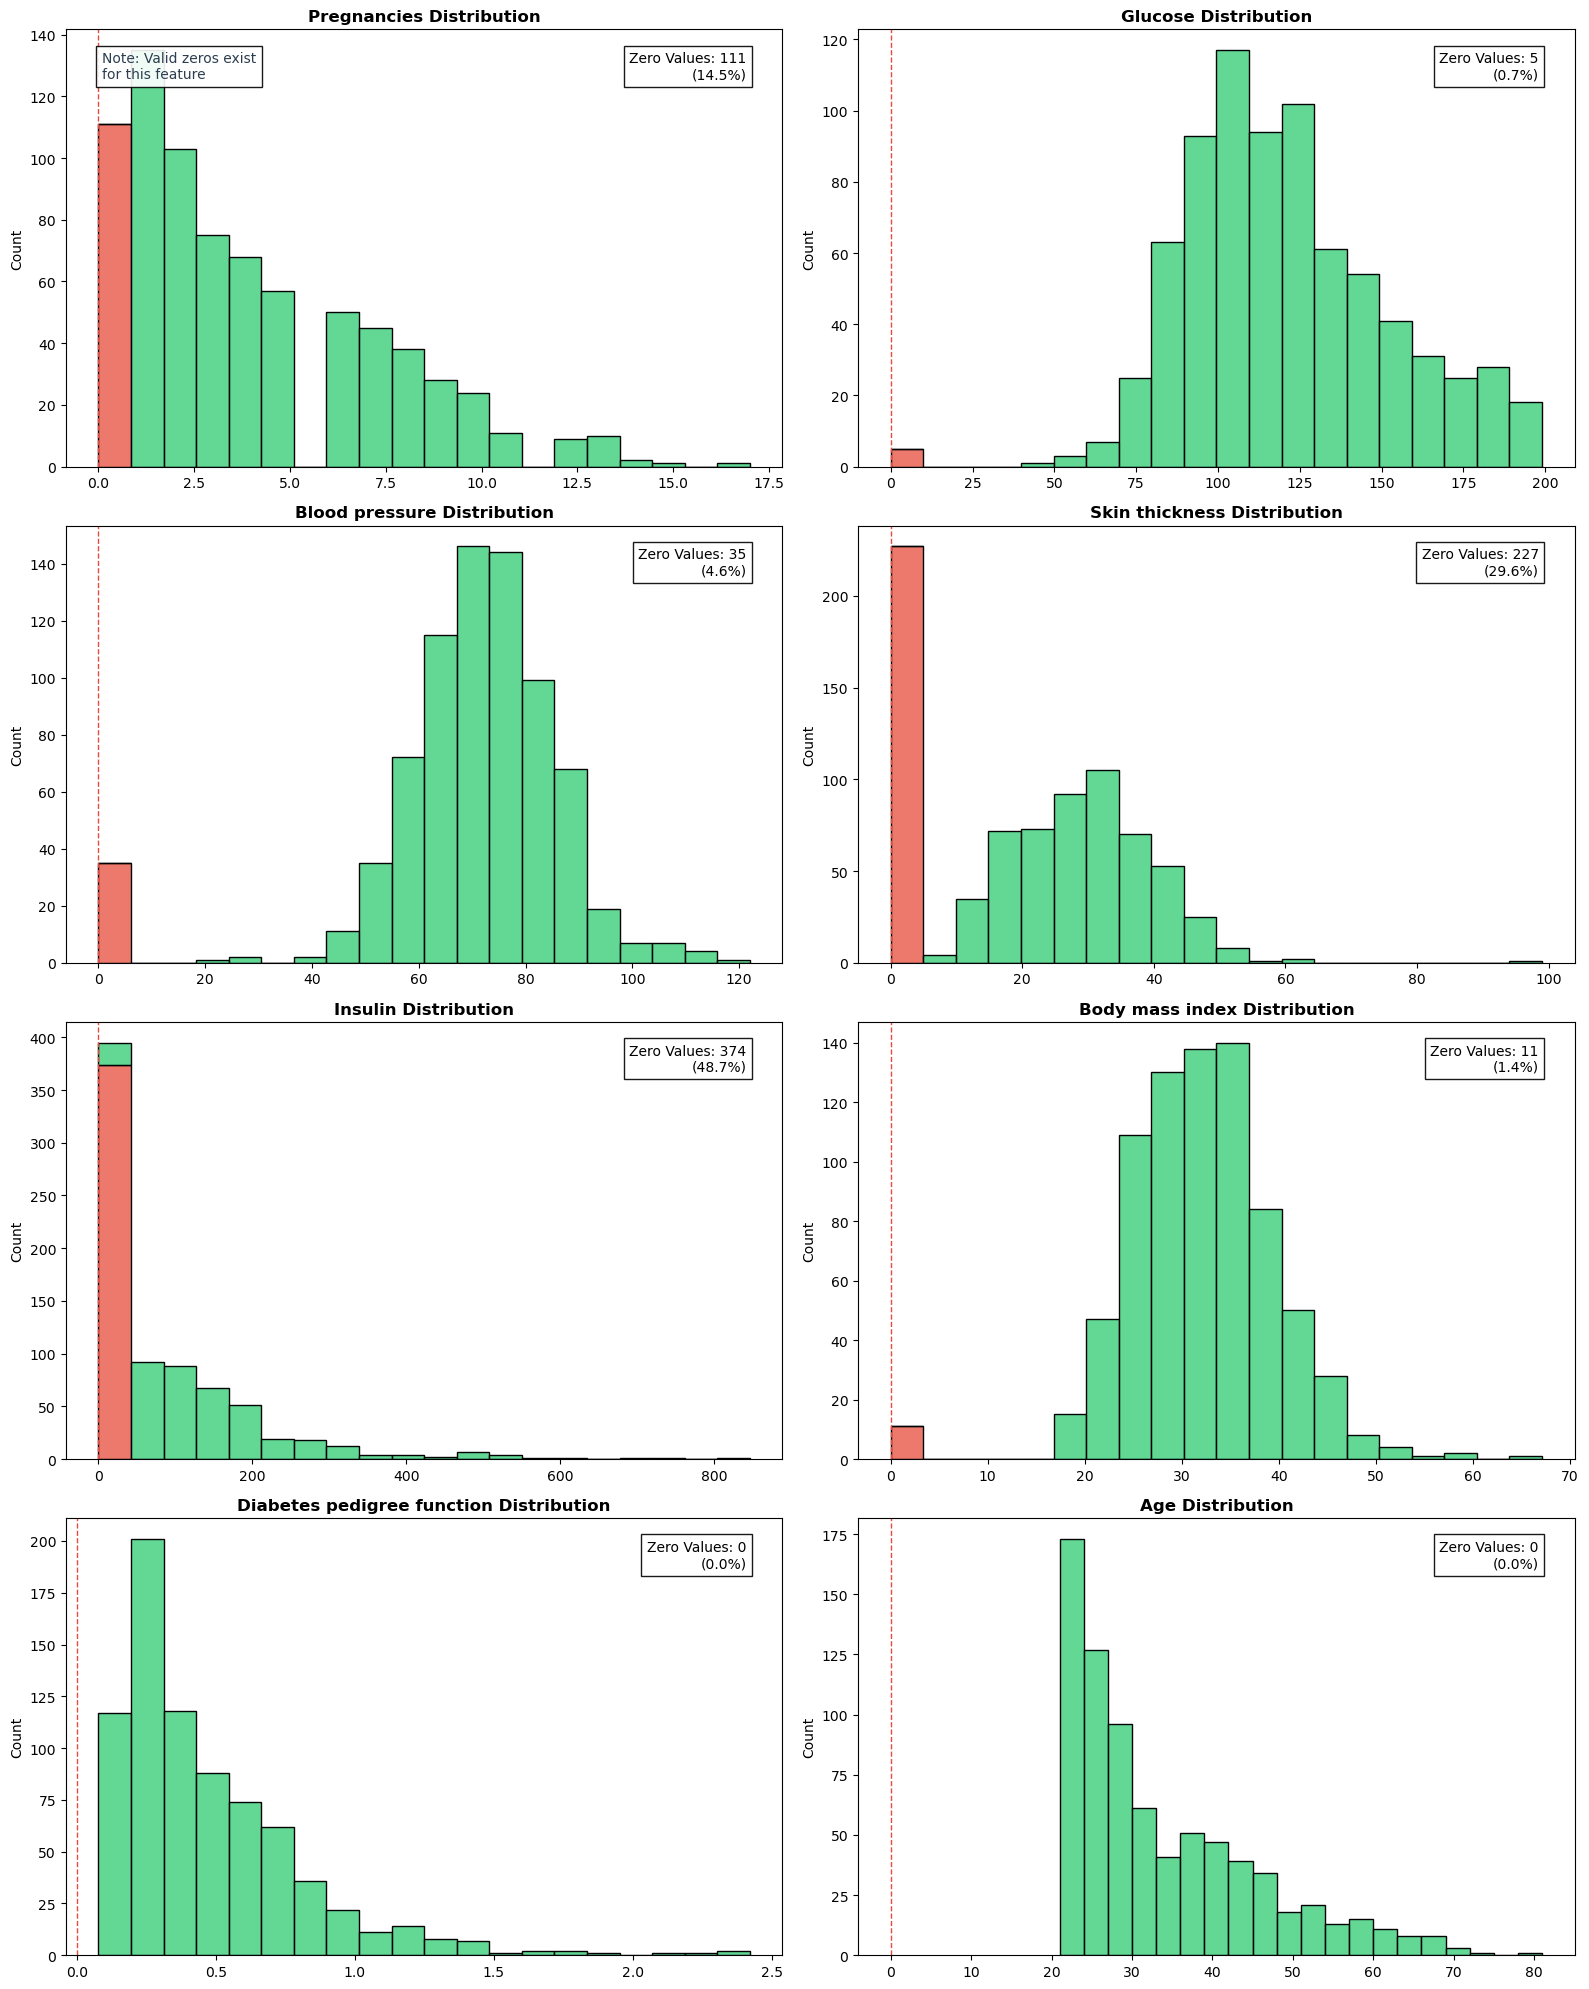

In [9]:
# Create subplot grid
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 20))
axes = axes.flatten()

# Create custom color palette
colors = ['#e74c3c' if x != 0 else '#2ecc71' for x in [0,1]]  # Green for data, red for zeros 

for i, feature in enumerate(features):
    # Calculate zero statistics
    zero_count = (X[feature] == 0).sum()
    zero_percent = zero_count / len(X) * 100
    
    # Create distribution plot
    sns.histplot(data=X, x=feature, bins=20, ax=axes[i], 
                 hue=(df[feature] == 0), palette=colors, 
                 legend=False, multiple='stack')
    
    # Add zero value annotations
    axes[i].axvline(0, color='#e74c3c', linestyle='--', linewidth=1)
    axes[i].text(0.95, 0.95, 
                f'Zero Values: {zero_count}\n({zero_percent:.1f}%)',
                transform=axes[i].transAxes,
                ha='right', va='top',
                bbox=dict(facecolor='white', alpha=0.9))
    
    # Formatting
    axes[i].set_title(f'{feature} Distribution', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    
    # Special handling for valid zeros in Pregnancies
    if feature == 'Pregnancies':
        axes[i].text(0.05, 0.95, 
                    'Note: Valid zeros exist\nfor this feature',
                    transform=axes[i].transAxes,
                    ha='left', va='top',
                    color='#2c3e50',
                    bbox=dict(facecolor='white', alpha=0.9))

# Remove empty subplot
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

* Some of the features seem to be containing 0 as values which might be incorrect as values for those features can't be 0 except for Pregnancies feature.
* Plotting the features to get an insight on the 0 values and distribution of those features.

## Separate training data and testing data to create unseen out of sample data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, stratify = y, random_state=42)

In [11]:
print(f"The training data has {X_train.shape[0]} rows and {X_train.shape[1]} columns")
print(f"The test data has {X_test.shape[0]} rows and {X_test.shape[1]} columns")

The training data has 537 rows and 8 columns
The test data has 231 rows and 8 columns


### Median Imputation

In [12]:
def dt_cleaning(data): # function for cleaning the data
    zero_features = ['Glucose', 'Blood pressure', 'Skin thickness', 'Insulin', 'Body mass index']
    for feature in zero_features:
        data[feature] = data[feature].replace(0, np.nan)
        median = data[feature].median()
        data[feature] = data[feature].fillna(median)
    return data

In [13]:
# Clean train data for median
X_train = dt_cleaning(X_train)

In [14]:
# Clean test data for median
X_test = dt_cleaning(X_test)

*Defining Metrics*

In [15]:
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'recall': make_scorer(recall_score),
    'precision': make_scorer(precision_score),
    'f1': make_scorer(f1_score),
    'roc_auc': make_scorer(roc_auc_score)
}

*Handling Class Imbalance*

In [16]:
scale_pos_weight = len(y_train[y_train==0])/len(y_train[y_train==1])

In [17]:
# Scaling the data
from sklearn.preprocessing import StandardScaler
from sklearn import preprocessing
sc = preprocessing.StandardScaler()
sc.fit(X_train)
X_train_sc = sc.transform(X_train)
X_test_sc = sc.transform(X_test)

In [ ]:
# defining the models
models = {
    "Logistic Regression": LogisticRegression(class_weight = 'balanced', random_state = 42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(class_weight = 'balanced', random_state = 42),
    "Random Forest": RandomForestClassifier(class_weight = 'balanced', random_state = 42),
    "XGBoost": XGBClassifier(scale_pos_weight = scale_pos_weight)
}

In [27]:
# Store model performance
performance = {}

# Stratified KFold to maintain the ratio of positive and negative class in each fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform K-Fold Cross Validation (5-fold) for each model
for name, model in models.items():
    accuracy = cross_val_score(model, X_train_sc, y_train, cv=skf, scoring="accuracy")
    recall = cross_val_score(model, X_train_sc, y_train, cv=skf, scoring="recall")
    precision = cross_val_score(model, X_train_sc, y_train, cv=skf, scoring="precision")
    roc_auc_scores = cross_val_score(model, X_train_sc, y_train, cv=skf, scoring="roc_auc")
    f1_scores = cross_val_score(model, X_train_sc, y_train, cv=skf, scoring="f1")
    
    # Store evaluation metrics (mean of cross-validation scores)
    performance[name] = {
        "Mean Accuracy": np.mean(accuracy),
        "Mean Recall": np.mean(recall),
        "Mean Precision": np.mean(precision),
        "Mean ROC AUC Score": np.mean(roc_auc_scores),
        "Mean F1 Score": np.mean(f1_scores)
    }

# Convert performance results to DataFrame
performance_df_skf = pd.DataFrame(performance).T

In [ ]:
# Display performance of all models
performance_df_skf

,Mean Accuracy,Mean Recall,Mean Precision,Mean ROC AUC Score,Mean F1 Score
Logistic Regression,0.754223,0.716785,0.633343,0.837175,0.669420
KNN,0.728297,0.578236,0.622775,0.786495,0.595303
Naive Bayes,0.743181,0.572404,0.667203,0.815592,0.607947
Decision Tree,0.670474,0.513514,0.539737,0.633900,0.521276
Random Forest,0.776705,0.594026,0.721959,0.828227,0.647639
XGBoost,0.730114,0.577809,0.626130,0.783394,0.597739


Convert scaled array back into dataframe

In [33]:
X_train_sc_df = pd.DataFrame(X_train_sc, columns = X_train.columns)
X_test_sc_df = pd.DataFrame(X_test_sc, columns = X_test.columns)

### Random Search CV for Logistic Regression

In [36]:
# Define search space for RandomizedSearchCV
param_distributions = {
    'C': stats.loguniform(1e-3, 1e3),  # Regularization strength
    'penalty': ['l1', 'l2'],  # Regularization type
    'solver': ['liblinear', 'lbfgs'],  # Compatible solver for l1 and l2
   'class_weight' : ['balanced'],
}

# Logistic Regression Model
logistic_regression = LogisticRegression(random_state=42)

# RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=logistic_regression,
    param_distributions=param_distributions,
    scoring=make_scorer(f1_score),  # Optimize for F1 Score
    n_iter=50,
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Fit RandomizedSearchCV
random_search.fit(X_train_sc_df, y_train)

# Best parameters and evaluation
best_params = random_search.best_params_
best_model_lr = random_search.best_estimator_

# Evaluate best model
y_pred = best_model_lr.predict(X_test_sc_df)
y_pred_proba = best_model_lr.predict_proba(X_test_sc_df)[:, 1]

performance = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC AUC Score": roc_auc_score(y_test, y_pred_proba),
}

# Print results
print("Best Parameters:", best_params)
print("Model Performance:", performance)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'C': 0.21481457181982683, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
Model Performance: {'Accuracy': 0.7272727272727273, 'Precision': 0.59375, 'Recall': 0.7037037037037037, 'F1 Score': 0.6440677966101694, 'ROC AUC Score': 0.8303703703703703}


In [ ]:
# Create DataFrame for Logistic Regression Model Scores
scores = pd.DataFrame.from_dict(performance, orient = 'index')
scores = scores.rename(columns = {0 : 'Logistic Regression'})
scores

,Logistic Regression
Accuracy,0.727273
Precision,0.593750
Recall,0.703704
F1 Score,0.644068
ROC AUC Score,0.830370


### Random Search CV for Random Forest

In [38]:
# Define the parameter search space
param_distributions_rf = {
    "n_estimators": stats.randint(50, 200),  # Number of trees in the forest
    "max_depth": stats.randint(5, 20),  # Maximum depth of the trees
    "min_samples_split": stats.randint(2, 10),  # Minimum samples required to split a node
    "min_samples_leaf": stats.randint(1, 10),  # Minimum samples required at a leaf node
    "max_features": ["sqrt", "log2", None],  # Number of features to consider at each split
    "class_weight": ['balanced'],
}

# Step 2: Define Random Forest and Parameter Distribution
random_forest = RandomForestClassifier(random_state=42)

# RandomizedSearchCV
random_search_rf = RandomizedSearchCV(
    estimator=random_forest,
    param_distributions=param_distributions_rf,
    scoring="f1",  # Optimize for F1 Score
    n_iter=50,  # Number of iterations
    cv=5,  # 5-fold cross-validation
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Fit RandomizedSearchCV
random_search_rf.fit(X_train_sc_df, y_train)

# Best parameters and evaluation
best_params = random_search_rf.best_params_
best_model_rf = random_search_rf.best_estimator_

# Evaluate best model
y_pred = best_model_rf.predict(X_test_sc_df)
y_pred_proba = best_model_rf.predict_proba(X_test_sc_df)[:, 1]

performance_rf = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC AUC Score": roc_auc_score(y_test, y_pred_proba),
}

# Print results
print("Best Parameters:", best_params)
print("Model Performance:", performance_rf)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'class_weight': 'balanced', 'max_depth': 11, 'max_features': 'sqrt', 'min_samples_leaf': 9, 'min_samples_split': 8, 'n_estimators': 67}
Model Performance: {'Accuracy': 0.7662337662337663, 'Precision': 0.6285714285714286, 'Recall': 0.8148148148148148, 'F1 Score': 0.7096774193548387, 'ROC AUC Score': 0.8666666666666666}


In [ ]:
# Create DataFrame for Random Forest Classification Model Scores
scores_rf = pd.DataFrame.from_dict(performance_rf, orient = 'index')
scores_rf = scores_rf.rename(columns = {0 : 'Random Forest'})
scores_rf

,Random Forest
Accuracy,0.766234
Precision,0.628571
Recall,0.814815
F1 Score,0.709677
ROC AUC Score,0.866667


In [41]:
# Define the parameter search space
param_dist_nb = {
    'var_smoothing': np.logspace(-9, 0, 50)  # Testing different variance smoothing values
}

# Initialize SVM Classifier
nb = GaussianNB()

# RandomizedSearchCV
random_search_nb = RandomizedSearchCV(
    estimator=nb,
    param_distributions=param_dist_nb,
    scoring="f1",  # Optimize for F1 Score
    n_iter=50,  # Number of iterations
    cv=5,  # 5-fold cross-validation
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Fit RandomizedSearchCV
random_search_nb.fit(X_train_sc_df, y_train)

# Best parameters and evaluation
best_params = random_search_nb.best_params_
best_model_nb = random_search_nb.best_estimator_

# Evaluate best model
y_pred = best_model_nb.predict(X_test_sc_df)
y_pred_proba = best_model_nb.predict_proba(X_test_sc_df)[:, 1]

performance_nb = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC AUC Score": roc_auc_score(y_test, y_pred_proba),
}

# Print results
print("Best Parameters:", best_params)
print("Model Performance:", performance_nb)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'var_smoothing': 0.009540954763499945}
Model Performance: {'Accuracy': 0.7272727272727273, 'Precision': 0.6, 'Recall': 0.6666666666666666, 'F1 Score': 0.631578947368421, 'ROC AUC Score': 0.7748148148148148}


In [ ]:
# Create DataFrame for Naive Bayes Model Scores
scores_nb = pd.DataFrame.from_dict(performance_nb, orient = 'index')
scores_nb = scores_nb.rename(columns = {0 : 'Naive Bayes'})
scores_nb

,Naive Bayes
Accuracy,0.727273
Precision,0.600000
Recall,0.666667
F1 Score,0.631579
ROC AUC Score,0.774815


### Final Comparison of Scores after RandomSearchCV for Logistic Regression, Random Forest and Naive Bayes

In [48]:
rf_lr_nb = pd.concat([scores, scores_rf, scores_nb], axis = 1)
rf_lr_nb

,Logistic Regression,Random Forest,Naive Bayes
Accuracy,0.727273,0.766234,0.727273
Precision,0.593750,0.628571,0.600000
Recall,0.703704,0.814815,0.666667
F1 Score,0.644068,0.709677,0.631579
ROC AUC Score,0.830370,0.866667,0.774815


### Plotting Comparison of F1 Scores for all three models

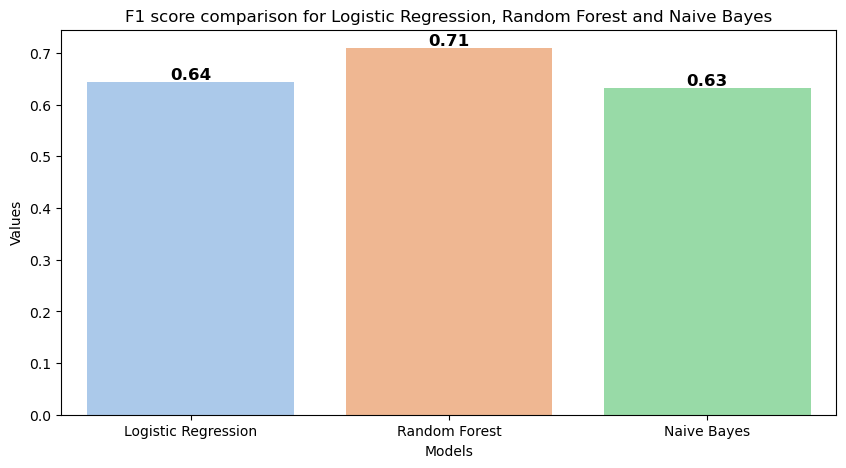

In [54]:
plt.figure(figsize = (10, 5))
# Extracting the fourth row (index 3)
row_index = 3
row_data = rf_lr_nb.iloc[row_index]

# Convert to DataFrame for Seaborn
row_df = pd.DataFrame({'Feature': row_data.index, 'Value': row_data.values})
ax = sns.barplot(x='Feature', y='Value', data=row_df, palette='pastel')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')
plt.xlabel("Models")
plt.ylabel("Values")
plt.title('F1 score comparison for Logistic Regression, Random Forest and Naive Bayes')
plt.show()

### Feature Importance Using Random Forest Model

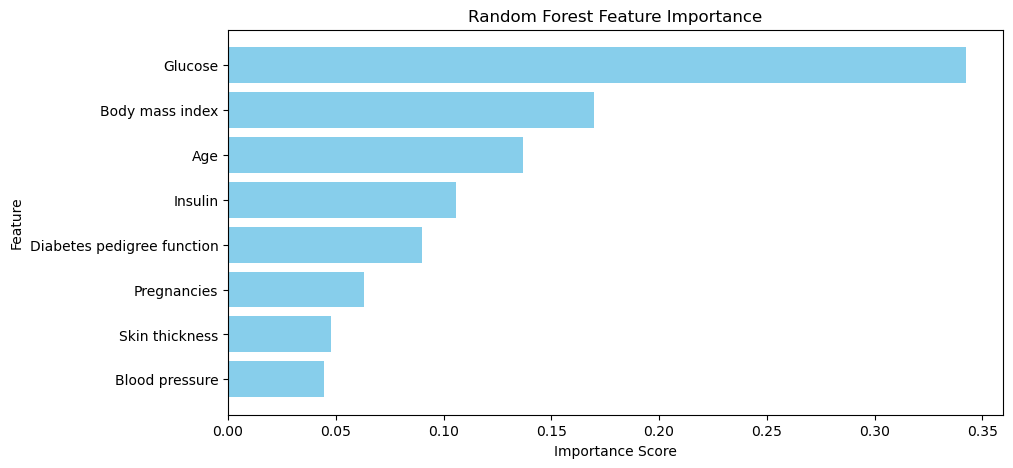

In [56]:
# Get feature importance
feature_importances = best_model_rf.feature_importances_
features = X_train_sc_df.columns

# Create a DataFrame for visualization
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot Feature Importance
plt.figure(figsize=(10, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()  # Invert y-axis for better readability
plt.show()

### Making prediction on test data using Random Forest model

In [ ]:
y_pred = best_model_rf.predict(X_test_sc_df) # predict values for test data
X_test_df = pd.DataFrame(X_test, columns=X.columns)  # Convert X_test back to DataFrame
# Create Actual Outcome and Predicted Outcome columns in the test dataframe
X_test_df['Actual_Outcome'] = y_test
X_test_df['Predicted_Outcome'] = y_pred
X_test_df.head()

,Pregnancies,Glucose,Blood pressure,Skin thickness,Insulin,Body mass index,Diabetes pedigree function,Age,Actual_Outcome,Predicted_Outcome
158,2,88,74.0,19.0,53.0,29.0,0.229,22,1,0
484,0,145,74.0,31.5,148.0,44.2,0.630,31,1,1
712,10,129,62.0,36.0,148.0,41.2,0.441,38,1,1
535,4,132,74.0,31.5,148.0,32.9,0.302,23,1,0
205,5,111,72.0,28.0,148.0,23.9,0.407,27,1,0
